<a href="https://colab.research.google.com/github/Lavesh789/Sales_forecasting_app/blob/main/salesforecasting_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

!pip install -q openpyxl scikit-learn seaborn matplotlib

Saving Sales_Forcasting_Dataset.xlsx to Sales_Forcasting_Dataset.xlsx


EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('Sales_Forcasting_Dataset.xlsx')
df['Date'] = pd.to_datetime(df['Date'])
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Row_ID               3000 non-null   int64         
 1   Date                 3000 non-null   datetime64[ns]
 2   Product_ID           3000 non-null   object        
 3   Product_Name         3000 non-null   object        
 4   Category             3000 non-null   object        
 5   Store_ID             3000 non-null   object        
 6   Store_Location       3000 non-null   object        
 7   Units_Sold           3000 non-null   int64         
 8   Price                3000 non-null   float64       
 9   Discount_Percentage  3000 non-null   int64         
 10  Revenue              3000 non-null   float64       
 11  Promotion_Flag       3000 non-null   int64         
 12  Stock_Availability   3000 non-null   int64         
 13  Day_of_Week          3000 non-nul

,0
Row_ID,0
Date,0
Product_ID,0
Product_Name,0
Category,0
Store_ID,0
Store_Location,0
Units_Sold,0
Price,0
Discount_Percentage,0


In [3]:
df.tail()

,Row_ID,Date,Product_ID,Product_Name,Category,Store_ID,Store_Location,Units_Sold,Price,Discount_Percentage,...,Holiday_Name,Is_Weekend,Season,Weather,Local_Event_Flag,Competitor_Price,Economic_Indicator,Sales_Channel,Customer_Segment,Marketing_Spend
2995,2996,2026-11-19,P004,Notebook Pack,Stationery,S03,Mumbai,44,4571.088282,7,...,NaN,1,Winter,Stormy,1,4140.519386,96.094306,Wholesale,Corporate,3493.381679
2996,2997,2026-11-21,P004,Notebook Pack,Stationery,S03,Mumbai,17,1145.408382,0,...,NaN,0,Winter,Cloudy,0,1189.247092,110.170382,Wholesale,Wholesale,340.763005
2997,2998,2026-11-21,P003,Office Chair,Furniture,S01,Chennai,29,2082.164246,1,...,NaN,0,Winter,Cloudy,1,1995.322801,108.803243,Wholesale,Wholesale,317.258914
2998,2999,2026-12-12,P004,Notebook Pack,Stationery,S04,Delhi,1,2181.012825,19,...,NaN,0,Winter,Sunny,0,1994.450427,96.667899,In-Store,Corporate,4763.565532
2999,3000,2026-12-25,P003,Office Chair,Furniture,S04,Delhi,53,4144.118169,18,...,NaN,0,Winter,Rainy,0,4226.482689,97.664667,Online,Wholesale,7096.556549


In [4]:
print(df['Quarter'].unique())

['Q1' 'Q2' 'Q3' 'Q4']


In [5]:
print(df['Product_Name'].unique())

['Bluetooth Speaker' 'LED Desk Lamp' 'Running Shoes' 'Notebook Pack'
 'Wireless Mouse' 'Yoga Mat' 'Coffee Maker' 'Office Chair']


In [6]:
print(df['Store_Location'].unique())

['Chennai' 'Delhi' 'Bengaluru' 'Mumbai']


In [7]:
print(df['Season'].unique())

['Winter' 'Spring' 'Summer' 'Autumn']


In [8]:
print(df['Sales_Channel'].unique())

['Online' 'In-Store' 'Wholesale']


In [9]:
print(df['Customer_Segment'].unique())

['Retail' 'Corporate' 'Wholesale']


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['Date'].duplicated().sum()

np.int64(1923)

In [12]:
df['Row_ID'].duplicated().sum()

np.int64(0)

In [13]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nSummary stats:\n", df.describe())

Shape: (3000, 27)

Missing values:
 Holiday_Name    2969
dtype: int64

Summary stats:
             Row_ID                        Date   Units_Sold        Price  \
count  3000.000000                        3000  3000.000000  3000.000000   
mean   1500.500000  2024-12-25 22:29:16.800000    42.068667  2573.711019   
min       1.000000         2023-01-06 00:00:00     0.000000   201.882929   
25%     750.750000         2024-06-08 00:00:00    15.000000  1291.656025   
50%    1500.500000         2024-12-21 00:00:00    43.000000  2548.635583   
75%    2250.250000         2025-07-19 00:00:00    64.000000  3773.608720   
max    3000.000000         2026-12-25 00:00:00   121.000000  4995.614847   
std     866.169729                         NaN    29.250319  1395.352185   

       Discount_Percentage        Revenue  Promotion_Flag  Stock_Availability  \
count          3000.000000    3000.000000     3000.000000         3000.000000   
mean              7.901333   93319.937417        0.713000         

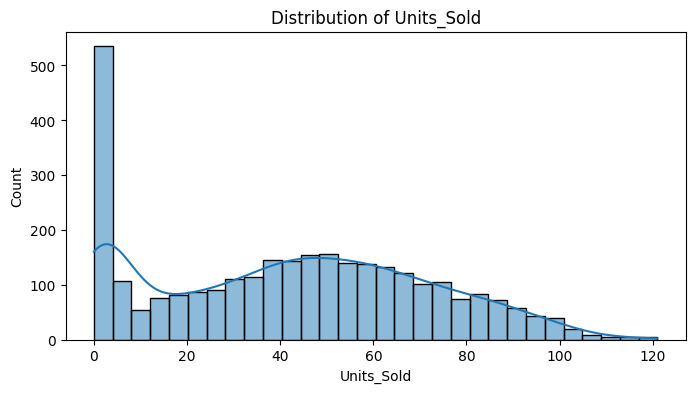

In [14]:
# Units_Sold distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Units_Sold'], bins=30, kde=True)
plt.title('Distribution of Units_Sold')
plt.show()

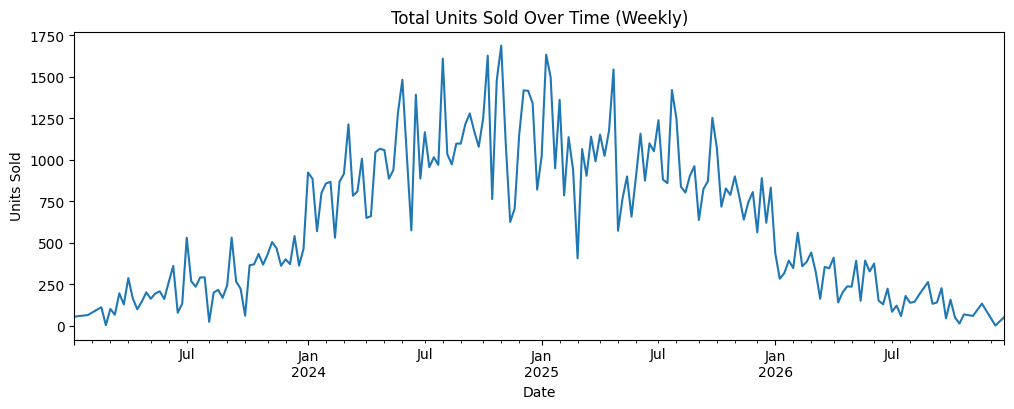

In [15]:
# Trend over time
monthly = df.groupby(df['Date'].dt.to_period('W'))['Units_Sold'].sum()
plt.figure(figsize=(12,4))
monthly.plot()
plt.title('Total Units Sold Over Time (Weekly)')
plt.ylabel('Units Sold')
plt.show()

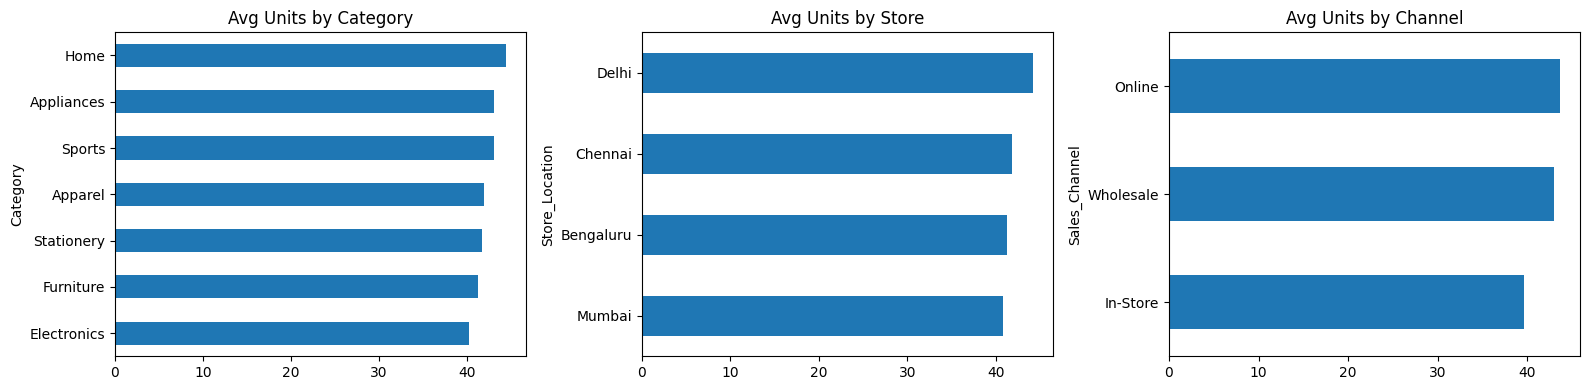

In [16]:
# Units sold by category / store / channel
fig, axes = plt.subplots(1, 3, figsize=(16,4))
df.groupby('Category')['Units_Sold'].mean().sort_values().plot(kind='barh', ax=axes[0], title='Avg Units by Category')
df.groupby('Store_Location')['Units_Sold'].mean().sort_values().plot(kind='barh', ax=axes[1], title='Avg Units by Store')
df.groupby('Sales_Channel')['Units_Sold'].mean().sort_values().plot(kind='barh', ax=axes[2], title='Avg Units by Channel')
plt.tight_layout()
plt.show()

In [17]:
# Correlation with target
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['Row_ID'])
corr_with_target = numeric_df.corr()['Units_Sold'].sort_values(ascending=False)
print("\nCorrelation with Units_Sold:\n", corr_with_target)


Correlation with Units_Sold:
 Units_Sold             1.000000
Stock_Availability     0.693741
Revenue                0.579453
Discount_Percentage    0.416296
Promotion_Flag         0.383766
Marketing_Spend        0.269368
Is_Weekend             0.215244
Local_Event_Flag       0.153969
Holiday_Flag           0.041688
Economic_Indicator    -0.027352
Price                 -0.306506
Competitor_Price      -0.309005
Name: Units_Sold, dtype: float64


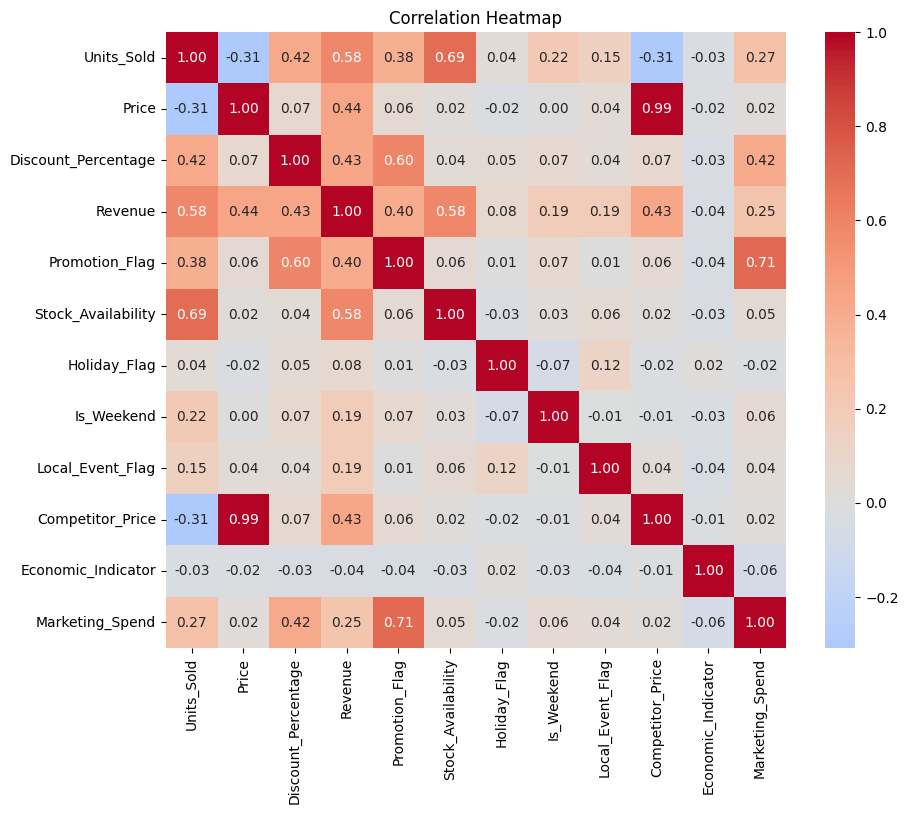

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

Feature Importance

Top 15 features driving Units_Sold:
 Stock_Availability            0.480647
Discount_Percentage           0.194901
Price                         0.104461
Competitor_Price              0.092268
Promotion_Flag                0.022519
Marketing_Spend               0.019760
Is_Weekend                    0.011311
Local_Event_Flag              0.011091
Economic_Indicator            0.009209
Holiday_Flag                  0.004742
Day_of_Week_Saturday          0.003003
Weather_Clear                 0.001891
Customer_Segment_Wholesale    0.001618
Month_September               0.001510
Season_Spring                 0.001508
dtype: float64


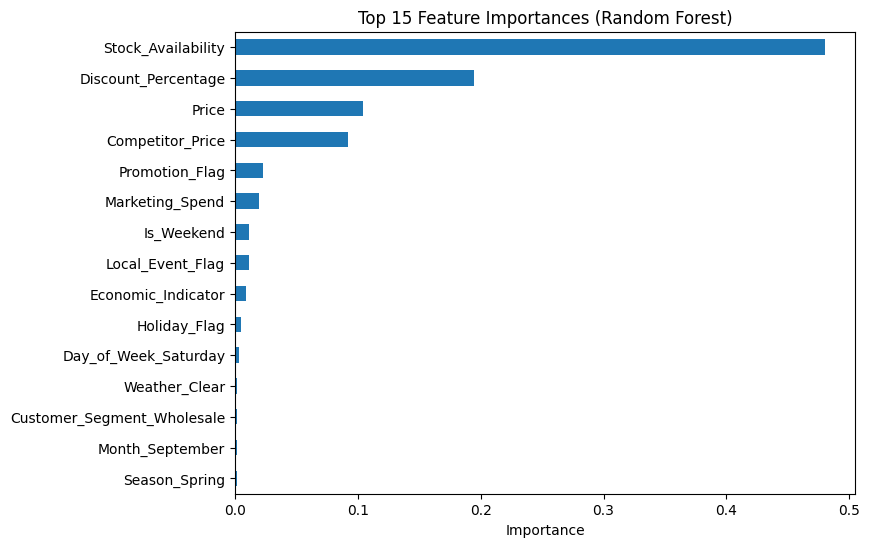

In [19]:
!pip install -q xgboost
!pip install scikit-learn
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor

target = 'Units_Sold'
drop_cols = ['Row_ID', 'Date', 'Units_Sold', 'Revenue', 'Holiday_Name']
X = df.drop(columns=drop_cols)
y = df[target]

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='passthrough')

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X, y)

ohe = rf_pipeline.named_steps['prep'].named_transformers_['cat']
feat_names = list(ohe.get_feature_names_out(cat_cols)) + num_cols
importances = pd.Series(rf_pipeline.named_steps['rf'].feature_importances_, index=feat_names)
importances = importances.sort_values(ascending=False)

print("Top 15 features driving Units_Sold:\n", importances.head(15))

plt.figure(figsize=(8,6))
importances.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()

In [47]:
print('numpy', np.__version__)
print('pandas', pd.__version__)
print('sklearn', sklearn.__version__)

numpy 2.1.3
pandas 2.2.3
sklearn 1.6.1


Build the Forecasting/Predictive Model

In [21]:
!pip install sktime
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from xgboost import XGBRegressor
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Random Forest': Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))]),
    'XGBoost': Pipeline([('prep', preprocessor),('model', XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,subsample=0.8, colsample_bytree=0.8,random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([('prep', preprocessor),('model', GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42))])
}

results = {}
fitted_models = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results[name] = {
        'MAE': mean_absolute_error(y_test, pred),
        'MSE':mean_squared_error(y_test, pred),
        'RMSE': mean_squared_error(y_test, pred) ** 0.5,
        'MAPE': mean_absolute_percentage_error(y_test, pred, symmetric=False),
        'SMAPE': mean_absolute_percentage_error(y_test, pred, symmetric=True),
        'R2': r2_score(y_test, pred)
    }
    fitted_models[name] = pipe

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print(results_df)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 9.8 MB/s eta 0:00:00
                        MAE        MSE      RMSE          MAPE     SMAPE  \
Random Forest      3.070106  18.492513  4.300292  3.377700e+14  0.224642   
XGBoost            3.119748  18.650482  4.318620  3.050949e+14  0.234232   
Gradient Boosting  4.443235  36.421329  6.035009  3.430151e+14  0.302519   

                         R2  
Random Forest      0.978231  
XGBoost            0.978046  
Gradient Boosting  0.957127  



 Best model: Random Forest (R² = 0.9782)


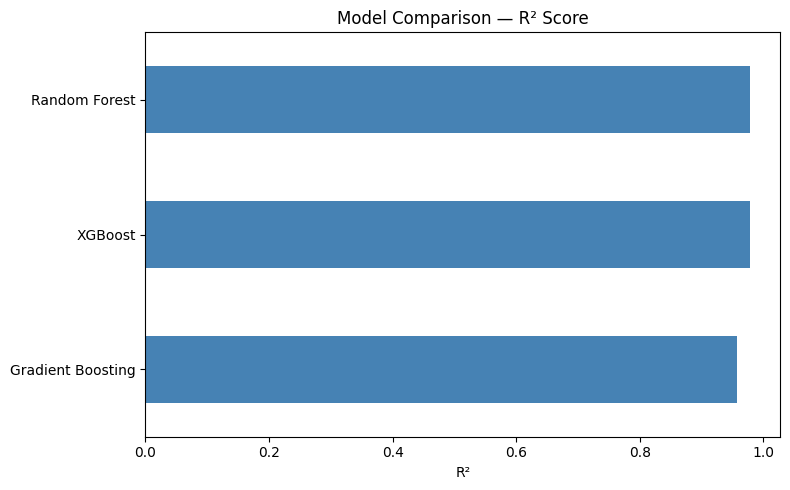

In [22]:
#Auto-select the best model
best_name = results_df['R2'].idxmax()
best_pipe = fitted_models[best_name]
print(f"\n Best model: {best_name} (R² = {results_df.loc[best_name, 'R2']:.4f})")

# Bar chart comparing all 4
plt.figure(figsize=(8,5))
results_df['R2'].sort_values().plot(kind='barh', color='steelblue')
plt.title('Model Comparison — R² Score')
plt.xlabel('R²')
plt.tight_layout()
plt.show()

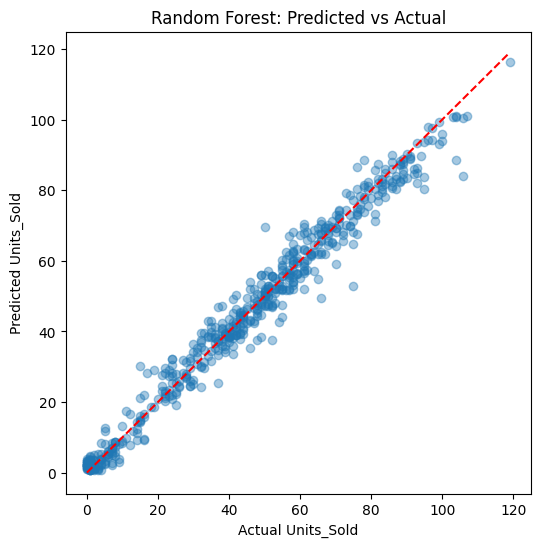

In [23]:
# Best model = Random Forest (typically). Plot predicted vs actual
best_pipe = models['Random Forest']
pred = best_pipe.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Units_Sold')
plt.ylabel('Predicted Units_Sold')
plt.title('Random Forest: Predicted vs Actual')
plt.show()

Combined Summary (EDA + Model insights together)

In [24]:
print("KEY INSIGHTS\n")
print("1. Top correlates of Units_Sold (linear):")
print(corr_with_target.drop('Units_Sold').head(5))

print("\n2. Top drivers (non-linear, Random Forest):")
print(importances.head(5))

print("\n3. Model performance:")
print(results_df)

print("\n4. Business takeaways:")
print("- Stock_Availability is the single biggest driver — stockouts are likely capping sales.")
print("- Discounting and promotions meaningfully lift Units_Sold.")
print("- Price and Competitor_Price move inversely with Units_Sold, as expected.")
print("- Economic_Indicator and Holiday_Flag have minimal individual predictive power here.")

KEY INSIGHTS

1. Top correlates of Units_Sold (linear):
Stock_Availability     0.693741
Revenue                0.579453
Discount_Percentage    0.416296
Promotion_Flag         0.383766
Marketing_Spend        0.269368
Name: Units_Sold, dtype: float64

2. Top drivers (non-linear, Random Forest):
Stock_Availability     0.480647
Discount_Percentage    0.194901
Price                  0.104461
Competitor_Price       0.092268
Promotion_Flag         0.022519
dtype: float64

3. Model performance:
                        MAE        MSE      RMSE          MAPE     SMAPE  \
Random Forest      3.070106  18.492513  4.300292  3.377700e+14  0.224642   
XGBoost            3.119748  18.650482  4.318620  3.050949e+14  0.234232   
Gradient Boosting  4.443235  36.421329  6.035009  3.430151e+14  0.302519   

                         R2  
Random Forest      0.978231  
XGBoost            0.978046  
Gradient Boosting  0.957127  

4. Business takeaways:
- Stock_Availability is the single biggest driver — stockou

Feature Engineering

In [25]:
import pandas as pd
import numpy as np

df = df.sort_values(['Product_ID', 'Store_ID', 'Date']).reset_index(drop=True)

# Resample Daily Data into Weekly Aggregations (Ending on Sunday 'W-SUN')
weekly_df = (
    df.resample("W-SUN", on="Date")
    .agg(
        {
            "Units_Sold": "sum",  # Total weekly sales target
            "Price": "mean",  # Average weekly price
            "Discount_Percentage": "mean",  # Average weekly discount
            "Promotion_Flag": "max",  # Active promo during the week (1 if any promo occurred)
            "Product_ID": "first",
            "Category": "first",
            "Store_ID": "first",
        }
    )
    .reset_index()
)

weekly_df['Year'] = df['Date'].dt.year
#df['Day'] = df['Date'].dt.day
#df['DayOfYear'] = df['Date'].dt.dayofyear
weekly_df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
weekly_df['Month_Num'] = df['Date'].dt.month
#df['DayOfWeek_Num'] = df['Date'].dt.dayofweek
weekly_df['Quarter'] = "Q" + weekly_df["Date"].dt.quarter.astype(str)

#Cyclical encoding (so Dec and Jan, or Sun and Mon, are "close" to a model)
#weekly_df['Month_sin'] = np.sin(2 * np.pi * df['Month_Num'] / 12)
#weekly_df['Month_cos'] = np.cos(2 * np.pi * df['Month_Num'] / 12)
#weekly_df['DOW_sin'] = np.sin(2 * np.pi * df['DayOfWeek_Num'] / 7)
#weekly_df['DOW_cos'] = np.cos(2 * np.pi * df['DayOfWeek_Num'] / 7)

#Price-related features
weekly_df['Price_Diff_vs_Competitor'] = df['Price'] - df['Competitor_Price']
weekly_df['Price_Ratio_vs_Competitor'] = df['Price'] / df['Competitor_Price']
weekly_df['Discounted_Price'] = df['Price'] * (1 - df['Discount_Percentage'] / 100)
#weekly_df['Discount_Amount'] = df['Price'] - df['Discounted_Price']

#Marketing efficiency
weekly_df['Marketing_Spend_per_Unit_Price'] = df['Marketing_Spend'] / df['Price']

#Interaction features (combined effects)
weekly_df['Promo_and_Weekend'] = df['Promotion_Flag'] * df['Is_Weekend']
weekly_df['Promo_and_Holiday'] = df['Promotion_Flag'] * df['Holiday_Flag']
weekly_df['InStock_and_Promo'] = df['Stock_Availability'] * df['Promotion_Flag']

#Lag & rolling features per Product + Store (time-series signal)
grp = df.groupby(['Product_ID', 'Store_ID'])
weekly_df['Units_Sold_Lag1'] = grp['Units_Sold'].shift(1)
weekly_df['Units_Sold_Lag7'] = grp['Units_Sold'].shift(7)
weekly_df['Units_Sold_RollMean_4'] = grp['Units_Sold'].transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
weekly_df['Units_Sold_RollStd_4']  = grp['Units_Sold'].transform(lambda x: x.shift(1).rolling(4, min_periods=1).std())

# Fill lag/rolling NaNs (first record(s) of each product/store group) with that group's mean
for c in ['Units_Sold_Lag1', 'Units_Sold_Lag7', 'Units_Sold_RollMean_4', 'Units_Sold_RollStd_4']:
    weekly_df[c] = weekly_df[c].fillna(grp['Units_Sold'].transform('mean'))

#Holiday flag consolidation
#weekly_df['Has_Holiday_Name'] = weekly_df['Holiday_Name'].notna().astype(int)

print("New shape:", df.shape)
#print("New columns added:", df.shape[1] - 25)
weekly_df[['Date','Product_ID','Store_ID','Units_Sold','Units_Sold_Lag1','Units_Sold_Lag7','Units_Sold_RollMean_4']].head(10)

New shape: (3000, 27)


,Date,Product_ID,Store_ID,Units_Sold,Units_Sold_Lag1,Units_Sold_Lag7,Units_Sold_RollMean_4
0,2023-01-08,P002,S01,54,42.566929,42.566929,42.566929
1,2023-01-15,P002,S01,58,51.000000,42.566929,51.000000
2,2023-01-22,None,None,0,33.000000,42.566929,42.000000
3,2023-01-29,P002,S01,64,23.000000,42.566929,35.666667
4,2023-02-05,None,None,0,22.000000,42.566929,32.250000
5,2023-02-12,P005,S04,96,18.000000,42.566929,24.000000
6,2023-02-19,P006,S02,111,24.000000,42.566929,21.750000
7,2023-02-26,P001,S02,3,36.000000,51.000000,25.000000
8,2023-03-05,P004,S01,101,47.000000,33.000000,31.250000
9,2023-03-12,P004,S02,66,44.000000,23.000000,37.750000


Evaluation Model

In [26]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)

    # MAPE: skip weeks where actual = 0 (division by zero is undefined,
    # not a model failure) — report how many were excluded
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100 if nonzero.sum() > 0 else np.nan

    eps = 1e-6
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    return {
        "MAE": mae, "MSE": mse, "RMSE": rmse,
        "MAPE": mape, "SMAPE": smape, "R2": r2,
    }

results = []

Model with Engineered Features

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error

target = 'Units_Sold'
# Drop identifiers/leakage, and raw Month_Num/DayOfWeek_Num (replaced by sin/cos versions)
drop_cols = ['Row_ID', 'Date', 'Units_Sold', 'Revenue', 'Holiday_Name']
             #['Month_Num', 'DayOfWeek_Num']
X = df.drop(columns=drop_cols)
y = df[target]

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='passthrough')

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Time-based Sequential Train/Test Split (80% Train, 20% Test on Weekly Data)
split_idx = int(len(weekly_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

models = {
    'Random Forest': Pipeline([('prep', preprocessor),('model', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))]),
    'XGBoost': Pipeline([('prep', preprocessor),('model', XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,subsample=0.8, colsample_bytree=0.8,random_state=42, n_jobs=-1))]),
     'Gradient Boosting': Pipeline([('prep', preprocessor),('model', GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42))])
}

results = {}
fitted_pipelines = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    #results[name] = {
      #  'MAE': mean_absolute_error(y_test, pred),
      # 'MSE': mean_squared_error(y_test, pred),
      #  'RMSE': mean_squared_error(y_test, pred) ** 0.5,
      #  'MAPE': mean_absolute_percentage_error(y_test, pred, symmetric=False),
      #  'SMAPE': mean_absolute_percentage_error(y_test, pred, symmetric=True),
      #  'R2': r2_score(y_test, pred)
    #}
    results[name] = evaluate_model(y_test, pred)
    fitted_pipelines[name] = pipe
# Classical Time Series Model on Weekly Target
ts_y = weekly_df.set_index("Date")["Units_Sold"]
ts_train, ts_test = ts_y.iloc[:split_idx], ts_y.iloc[split_idx:]

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print(results_df)

                         MAE         MSE       RMSE        MAPE      SMAPE  \
Gradient Boosting   9.931338  167.868306  12.956400   80.123475  48.439311   
Random Forest      10.002409  174.500630  13.209869   62.730593  42.312388   
XGBoost            10.689589  180.697605  13.442381  121.683844  47.530092   

                         R2  
Gradient Boosting  0.804831  
Random Forest      0.797120  
XGBoost            0.789915  



 Best model: Gradient Boosting (R² = 0.8048)


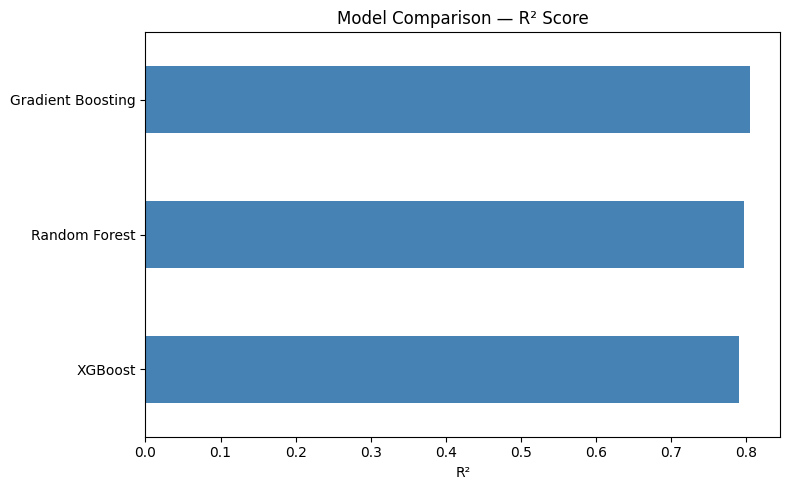

In [28]:
#Auto-select the best model
best_name = results_df['R2'].idxmax()
best_pipe = fitted_models[best_name]
print(f"\n Best model: {best_name} (R² = {results_df.loc[best_name, 'R2']:.4f})")

# Bar chart comparing all 4
plt.figure(figsize=(8,5))
results_df['R2'].sort_values().plot(kind='barh', color='steelblue')
plt.title('Model Comparison — R² Score')
plt.xlabel('R²')
plt.tight_layout()
plt.show()

In [29]:
# Refit feature importance on the richer feature set
best_pipe = models['Gradient Boosting']
ohe = best_pipe.named_steps['prep'].named_transformers_['cat']
feat_names = list(ohe.get_feature_names_out(cat_cols)) + num_cols
importances = pd.Series(best_pipe.named_steps['model'].feature_importances_, index=feat_names).sort_values(ascending=False)
print("\nTop 15 features:\n", importances.head(15))


Top 15 features:
 Stock_Availability        0.451923
Discount_Percentage       0.178962
Price                     0.121847
Competitor_Price          0.107041
Marketing_Spend           0.041385
Quarter_Q4                0.018616
Day_of_Week_Saturday      0.014433
Economic_Indicator        0.010573
Sales_Channel_In-Store    0.009449
Day_of_Week_Tuesday       0.006795
Month_July                0.005896
Season_Summer             0.004698
Season_Autumn             0.003677
Season_Winter             0.003557
Weather_Clear             0.003418
dtype: float64


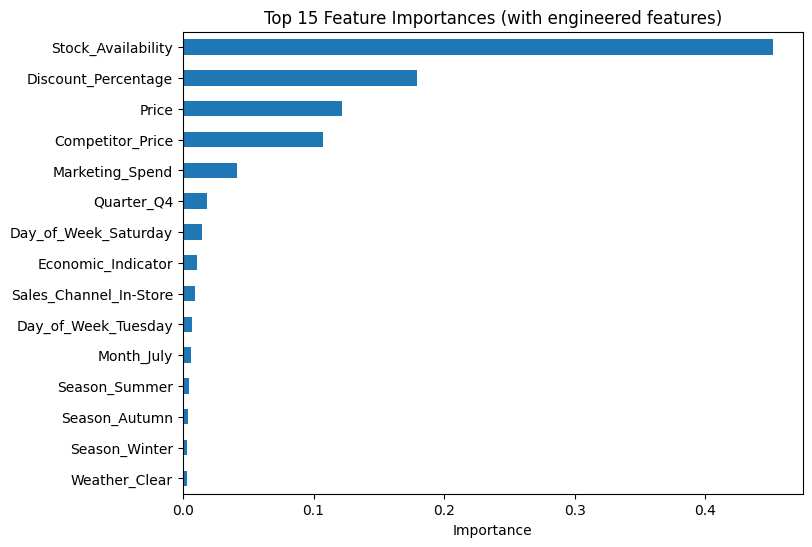

In [30]:
plt.figure(figsize=(8,6))
importances.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances (with engineered features)')
plt.xlabel('Importance')
plt.show()

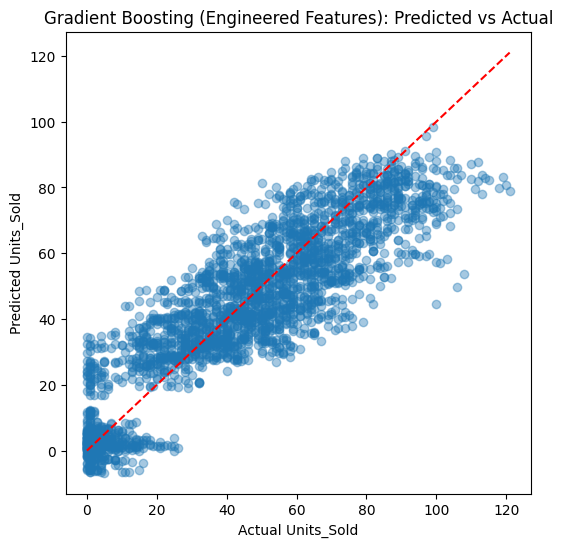

In [31]:
# Predicted vs actual
pred = best_pipe.predict(X_test)
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Units_Sold')
plt.ylabel('Predicted Units_Sold')
plt.title('Gradient Boosting (Engineered Features): Predicted vs Actual')
plt.show()

Time-series Forecasting

Weekly series length: 208
count     208.000000
mean      606.759615
std       447.688729
min         0.000000
25%       198.750000
50%       535.500000
75%       949.750000
max      1688.000000
Name: Units_Sold, dtype: float64


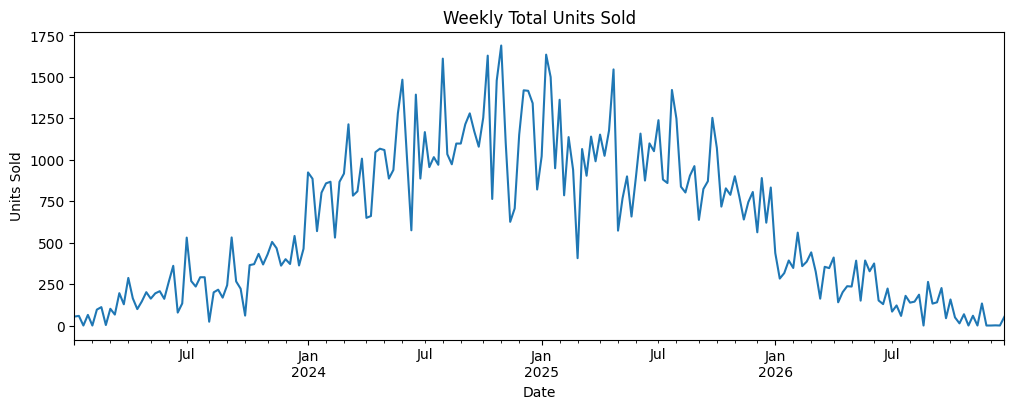

Train: 167 weeks | Test: 41 weeks


In [32]:
!pip install -q prophet statsmodels tensorflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_excel('Sales_Forcasting_Dataset.xlsx')
df['Date'] = pd.to_datetime(df['Date'])

# Aggregate to a single weekly time series (sum of Units_Sold across all
# products/stores) — ARIMA/Prophet/LSTM need one continuous series, not
# per-transaction rows. Missing weeks are filled with 0 (no recorded sales).
weekly = df.set_index('Date')['Units_Sold'].resample('W').sum().fillna(0)
weekly.index.name = 'Date'

print("Weekly series length:", len(weekly))
print(weekly.describe())

plt.figure(figsize=(12, 4))
weekly.plot()
plt.title('Weekly Total Units Sold')
plt.ylabel('Units Sold')
plt.show()

# Chronological train/test split (last 20% as test — standard for time series)
test_size = int(len(weekly) * 0.2)
train, test = weekly.iloc[:-test_size], weekly.iloc[-test_size:]
print(f"Train: {len(train)} weeks | Test: {len(test)} weeks")

Metrics Function

In [33]:
def evaluate(y_true, y_pred, model_name="Model"):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)

    # MAPE: skip weeks where actual = 0 (division by zero is undefined,
    # not a model failure) — report how many were excluded
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100 if nonzero.sum() > 0 else np.nan

    eps = 1e-6
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    return {
        "Model": model_name, "MAE": mae, "MSE": mse, "RMSE": rmse,
        "MAPE": mape, "SMAPE": smape, "R2": r2,
    }

results = []

Arima

In [34]:
from statsmodels.tsa.arima.model import ARIMA

try:
    arima_model = ARIMA(train, order=(2, 1, 2))
    arima_fit = arima_model.fit()
    arima_pred = arima_fit.forecast(steps=len(test))
    results.append(evaluate(test.values, arima_pred.values, "ARIMA"))
    print("ARIMA done.")
except Exception as e:
    print("ARIMA failed:", e)
    arima_pred = pd.Series(np.full(len(test), train.mean()), index=test.index)

ARIMA done.


Prophet

In [35]:
from prophet import Prophet

try:
    prophet_train = train.reset_index()
    prophet_train.columns = ['ds', 'y']

    prophet_model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
    prophet_model.fit(prophet_train)

    future = pd.DataFrame({'ds': test.index})
    forecast = prophet_model.predict(future)
    prophet_pred = forecast['yhat'].values
    prophet_pred = np.clip(prophet_pred, 0, None)  # sales can't be negative

    results.append(evaluate(test.values, prophet_pred, "Prophet"))
    print("Prophet done.")
except Exception as e:
    print("Prophet failed:", e)
    prophet_pred = np.full(len(test), train.mean())

Prophet done.


LSTM

In [36]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

try:
    tf.random.set_seed(42)

    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))

    WINDOW = 8  # use past 8 weeks to predict the next week
    def make_sequences(data, window):
        X, y = [], []
        for i in range(window, len(data)):
            X.append(data[i-window:i, 0])
            y.append(data[i, 0])
        return np.array(X), np.array(y)

    X_train, y_train = make_sequences(train_scaled, WINDOW)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

    lstm_model = Sequential([
        LSTM(50, activation='relu', input_shape=(WINDOW, 1)),
        Dense(1)
    ])
    lstm_model.compile(optimizer='adam', loss='mse')
    lstm_model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)

    # Recursive forecast: walk forward one week at a time using the model's
    # own prior predictions once we run out of real history
    history = list(train_scaled.flatten()[-WINDOW:])
    lstm_preds_scaled = []
    for _ in range(len(test)):
        x_input = np.array(history[-WINDOW:]).reshape((1, WINDOW, 1))
        next_pred = lstm_model.predict(x_input, verbose=0)[0, 0]
        lstm_preds_scaled.append(next_pred)
        history.append(next_pred)

    lstm_pred = scaler.inverse_transform(np.array(lstm_preds_scaled).reshape(-1, 1)).flatten()
    lstm_pred = np.clip(lstm_pred, 0, None)

    results.append(evaluate(test.values, lstm_pred, "LSTM"))
    print("LSTM done.")
except Exception as e:
    print("LSTM failed:", e)
    lstm_pred = np.full(len(test), train.mean())

LSTM done.


Compare Models

                MAE            MSE        RMSE         MAPE       SMAPE  \
Model                                                                     
ARIMA    196.034759   49138.745595  221.672609  1193.395590   95.173286   
Prophet  321.034191  115050.873403  339.191500  1319.467354  116.471695   
LSTM     455.339172  267094.090021  516.811465  2864.289967  119.732114   

                R2  
Model               
ARIMA    -2.220693  
Prophet  -6.540760  
LSTM    -16.506104  


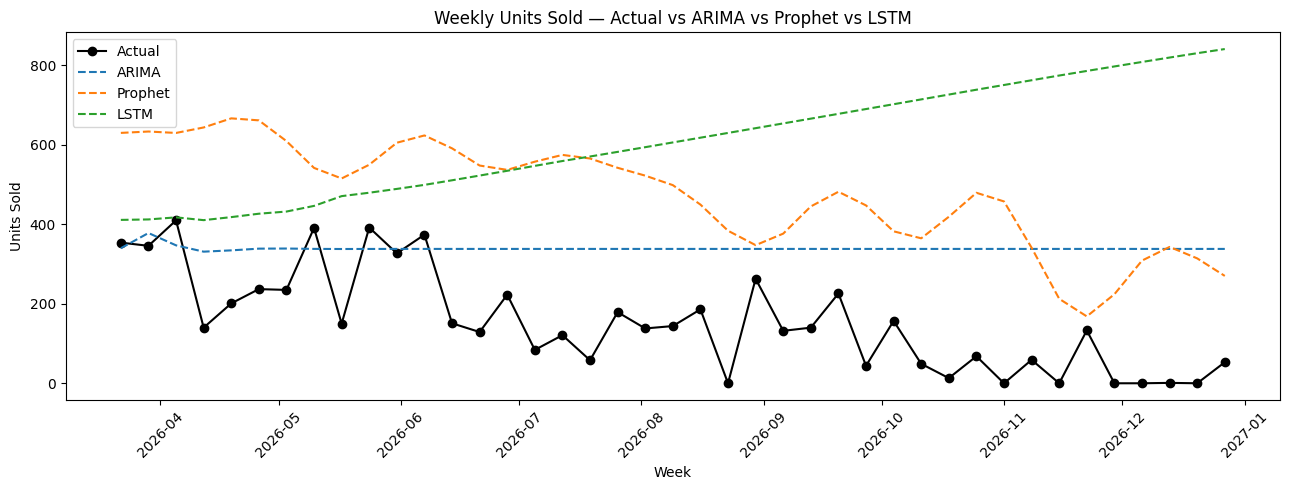


Best time-series model by RMSE: ARIMA


In [37]:
results_df = pd.DataFrame(results).set_index("Model")
print(results_df)

plt.figure(figsize=(13, 5))
#plt.plot(train.index[-20:], train.values[-20:], label="Train (recent)", color="gray")
plt.plot(test.index, test.values, label="Actual", color="black", marker="o")
plt.plot(test.index, arima_pred, label="ARIMA", linestyle="--")
plt.plot(test.index, prophet_pred, label="Prophet", linestyle="--")
plt.plot(test.index, lstm_pred, label="LSTM", linestyle="--")
plt.title("Weekly Units Sold — Actual vs ARIMA vs Prophet vs LSTM")
plt.xlabel("Week")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_ts_model = results_df["RMSE"].idxmin()
print(f"\nBest time-series model by RMSE: {best_ts_model}")

Hyperparameter Tuning & Final Model

In [43]:
import itertools
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sktime.performance_metrics.forecasting import (
    mean_absolute_percentage_error,
)
from xgboost import XGBRegressor

# ==========================================
# 1. Clean NaN values and ensure correct types
# ==========================================
# Fill time-series lag/rolling NaNs before splitting
X = X.bfill().ffill()

# Dynamically select all categorical text columns to prevent passing raw strings into models
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

# Robust preprocessor that explicitly handles unassigned text columns
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),cat_cols,)
    ],
    remainder="passthrough",
)

# Re-split cleaned data
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ==========================================
# 2. Hyperparameter Tuning Pipeline Setup
# ==========================================
if best_name == "Random Forest":
    tune_pipe = Pipeline(
        [("prep", preprocessor), ("model", RandomForestRegressor(random_state=42, n_jobs=-1))]
    )
    param_dist = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
    }

elif best_name == "XGBoost":
    tune_pipe = Pipeline(
        [("prep", preprocessor), ("model", XGBRegressor(random_state=42, n_jobs=-1))]
    )
    param_dist = {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [3, 6, 9],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.7, 0.8, 1.0],
    }

elif best_name == "Gradient Boosting":
    tune_pipe = Pipeline(
        [("prep", preprocessor), ("model", GradientBoostingRegressor(random_state=42))]
    )
    param_dist = {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [3, 4, 5],
        "model__learning_rate": [0.01, 0.05, 0.1],
    }

else:
    tune_pipe = None
    param_dist = None

# ==========================================
# 3. Fit Model with Debugging Enabled
# ==========================================
if tune_pipe is not None:
    # Use TimeSeriesSplit for cross-validation on temporal sequential data
    tscv = TimeSeriesSplit(n_splits=3)

    search = RandomizedSearchCV(
        estimator=tune_pipe,
        param_distributions=param_dist,
        n_iter=5,
        cv=tscv,
        scoring="r2",
        random_state=42,
        n_jobs=-1,
        error_score="raise",  # Will raise exact line error if fit fails
    )

    search.fit(X_train, y_train)

    print("Best params:", search.best_params_)
    best_model = search.best_estimator_
    pred = best_model.predict(X_test)

    # Output metrics
    print("Final Model:", best_name)
    print("Tuned MAE:", mean_absolute_error(y_test, pred))
    print("Tuned RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print("Tuned MAPE:", mean_absolute_percentage_error(y_test, pred, symmetric=False))
    print("Tuned SMAPE:", mean_absolute_percentage_error(y_test, pred, symmetric=True))
    print("Tuned R2:", r2_score(y_test, pred))

    # Save the final model for later reuse
    joblib.dump(best_model, 'sales_forecast_model.pkl')
    print("Model saved as sales_forecast_model.pkl")

    # To reload later: best_model = joblib.load('sales_forecast_model.pkl')

Best params: {'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.1}
Final Model: Gradient Boosting
Tuned MAE: 10.157194457924724
Tuned RMSE: 13.237709898543388
Tuned MAPE: 870013225507188.4
Tuned SMAPE: 0.49078493535382683
Tuned R2: 0.7962640491431802
Model saved as sales_forecast_model.pkl


Generate Predictions & Package for Business Use

In [44]:
#Reusable prediction function
def predict_units_sold(new_data: pd.DataFrame, model_path='sales_forecast_model.pkl'):

    model = joblib.load(model_path)
    return model.predict(new_data)

# Quick sanity check on a few held-out rows
sample = X_test.iloc[:5]
print("Sample predictions:", predict_units_sold(sample))

Sample predictions: [100.76203289  71.12994225  25.40897061  49.9734384   53.08324114]


In [45]:
#Full test-set results table, with error column
test_results = X_test.copy()
test_results['Actual_Units_Sold'] = y_test.values
test_results['Predicted_Units_Sold'] = best_model.predict(X_test).round(1)
test_results['Abs_Error'] = (test_results['Actual_Units_Sold'] - test_results['Predicted_Units_Sold']).abs()

test_results.to_excel('sales_forecast_predictions.xlsx', index=False)
print("Saved: sales_forecast_predictions.xlsx —", test_results.shape)

Saved: sales_forecast_predictions.xlsx — (2834, 25)


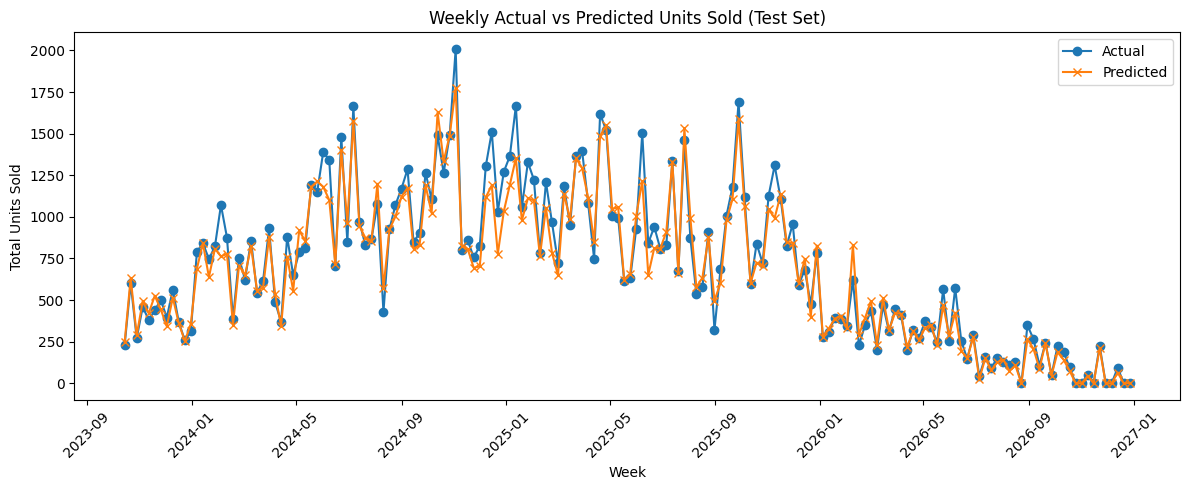

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
#Actual vs Predicted over time (weekly aggregate, for a trend chart)
comp = df.loc[X_test.index, ['Date']].copy()
comp['Actual'] = y_test.values
comp['Predicted'] = best_model.predict(X_test)
comp = comp.sort_values('Date')

weekly = comp.set_index('Date').resample('W').sum(numeric_only=True)

plt.figure(figsize=(12, 5))
plt.plot(weekly.index, weekly['Actual'], label='Actual', marker='o')
plt.plot(weekly.index, weekly['Predicted'], label='Predicted', marker='x')
plt.title('Weekly Actual vs Predicted Units Sold (Test Set)')
plt.xlabel('Week')
plt.ylabel('Total Units Sold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Download the files from Colab
#from google.colab import files
#files.download('sales_forecast_model.pkl')
#files.download('sales_forecast_predictions.xlsx')